XGBoost Model Accuracy: 0.8444085840217732
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4577
         1.0       0.58      0.31      0.41      4513
         2.0       0.85      0.97      0.90     29877
         3.0       0.51      0.04      0.07      1933
         4.0       0.45      0.21      0.29       485
         5.0       0.44      0.22      0.29       134

    accuracy                           0.84     41519
   macro avg       0.64      0.46      0.49     41519
weighted avg       0.81      0.84      0.81     41519



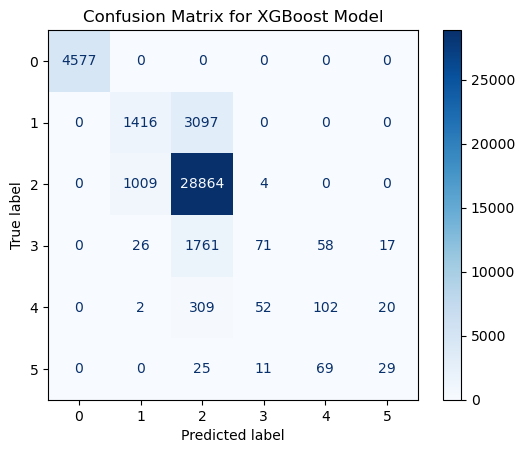

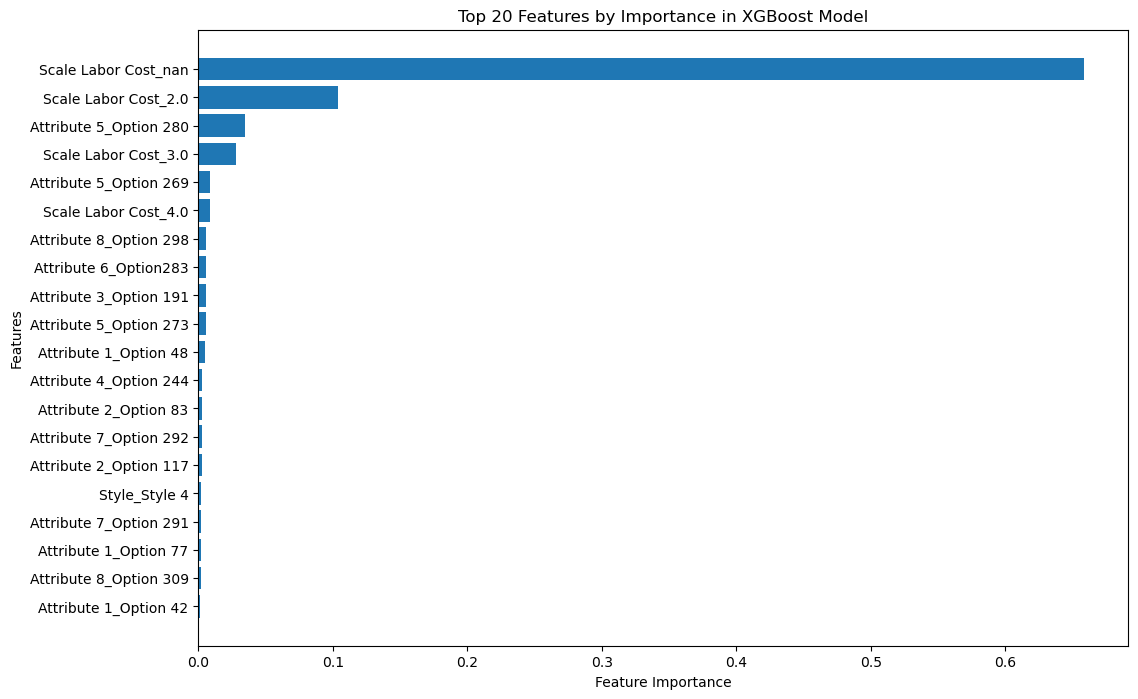

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Load and Merge Datasets
option_code_info_df = pd.read_csv('Option Code Information file for UNT - Final(Sheet1).csv')
claim_info_df = pd.read_csv('Claim Information file for UNT(Sheet1).csv')

# Rename and merge data
option_code_info_df.rename(columns={'Truck': 'Truck Number'}, inplace=True)
merged_df = pd.merge(option_code_info_df, claim_info_df, on='Truck Number', how='left')

# Step 2: Ordinal Encoding
ordinal_mapping = {'Very Low': 1, 'Low': 2, 'Medium': 3, 'High': 4, 'Very High': 5}
merged_df['Scale Claim Cost'] = merged_df['Scale Claim Cost'].map(ordinal_mapping)
merged_df['Scale Labor Cost'] = merged_df['Scale Labor Cost'].map(ordinal_mapping)
merged_df['Scale Claim Cost'].fillna(0, inplace=True)  # Assuming 0 represents no claims

# Step 3: Feature Selection and One-Hot Encoding
X = merged_df.drop(columns=['Truck Number', 'Claim Number', 'Scale Claim Cost'])
y = merged_df['Scale Claim Cost']

# One-Hot Encode categorical variables
encoder = OneHotEncoder(sparse_output=False, drop='first')  # Using sparse_output=False for a dense matrix
X_encoded = encoder.fit_transform(X)
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(X.columns))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded_df, y, test_size=0.3, random_state=42)

# Step 4: Train the XGBoost Model
xgb_model = XGBClassifier(
    max_depth=10,            # Control the complexity
    n_estimators=100,         # Number of boosting rounds
    learning_rate=0.1,        # Shrinkage rate to prevent overfitting
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Step 5: Evaluate the Model
y_pred = xgb_model.predict(X_test)

print("XGBoost Model Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix for XGBoost Model")
plt.show()

# Step 6: Feature Importance Visualization
# Plotting the top 20 features by importance
importance_df = pd.DataFrame({
    'Feature': X_encoded_df.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'][:20], importance_df['Importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 20 Features by Importance in XGBoost Model')
plt.show()
